In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")

print("Path to dataset files:", path)

import pandas as pd
import os

# 1. Lister les fichiers dans le dossier pour trouver le nom exact du CSV
files = os.listdir(path)
print("Fichiers téléchargés :", files)

# 2. Charger le premier fichier CSV trouvé
# (En supposant que le fichier s'appelle 'spotify_songs.csv')
csv_path = os.path.join(path, "spotify_songs.csv")
data = pd.read_csv(csv_path)

# 3. Afficher les premières lignes
data.head()

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
#Taille du jeu de données : 33k lignes et 23 clonnes qu on affiche
data.shape
data.columns

Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')

In [ ]:
n_duplicated = data.duplicated().sum()
print(f"Number of duplicated rows: {n_duplicated}\n")

df = pd.DataFrame({
    'n_unique':data.nunique(),
    'n_missing':data.isna().sum(),
    'missing_ratio':data.isna().mean(),
    'dtype':data.dtypes.values
})

display(
    df.style.background_gradient(cmap='BuPu')
        .format({"missing_ratio": "{:.2%}"})
)

#On remarque peu de trous : juste 5 sur les colonnes track_name, track_artist et track_album_name: 
#les enlever n aura surement pas trop d impact au besoin

Number of duplicated rows: 0



,n_unique,n_missing,missing_ratio,dtype
track_id,28356,0,0.00%,object
track_name,23449,5,0.02%,object
track_artist,10692,5,0.02%,object
track_popularity,101,0,0.00%,int64
track_album_id,22545,0,0.00%,object
track_album_name,19743,5,0.02%,object
track_album_release_date,4530,0,0.00%,object
playlist_name,449,0,0.00%,object
playlist_id,471,0,0.00%,object
playlist_genre,6,0,0.00%,object


In [ ]:
#On supprime les colonnes AAAUUUUU BEEESSSOINNNN qui ne servent 
#a rien pour l analyse voir track id et track album id
'''
cols_to_drop = [
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
]
data = data.drop(columns=cols_to_drop)

display(
    data.head().style.background_gradient(cmap="BuPu")
)'''

'\ncols_to_drop = [\n    "EmployeeCount",\n    "Over18",\n    "StandardHours",\n    "EmployeeNumber"\n]\ndata = data.drop(columns=cols_to_drop)\n\ndisplay(\n    data.head().style.background_gradient(cmap="BuPu")\n)'

In [ ]:
# 3. LA MÉTHODE MAGIQUE : Conversion des types pour bine séparer les variables qualitatives et quantitatives 

# Cela transforme les 'object' en 'string' et optimise les nombres
data = data.convert_dtypes()

# A. Récupérer uniquement les colonnes de TEXTE (Nom, Artiste, Genre...)
data_texte = data.select_dtypes(include='string')

# B. Récupérer uniquement les colonnes de NOMBRES (Energie, Danse, Tempo...)
data_chiffres = data.select_dtypes(include='number')

# --- AFFICHAGE ---
print("--- COLONNES DE TEXTE ---")
display(data_texte.head())

print("\n--- COLONNES NUMÉRIQUES ---")
display(data_chiffres.head())

--- COLONNES DE TEXTE ---


,track_id,track_name,track_artist,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop



--- COLONNES NUMÉRIQUES ---


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,66,0.748,0.916,6,-2.634,1,0.0583,0.102,0.0,0.0653,0.518,122.036,194754
1,67,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.00421,0.357,0.693,99.972,162600
2,70,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.11,0.613,124.008,176616
3,60,0.718,0.93,7,-3.778,1,0.102,0.0287,0.000009,0.204,0.277,121.956,169093
4,69,0.65,0.833,1,-4.672,1,0.0359,0.0803,0.0,0.0833,0.725,123.976,189052


In [ ]:
#Proportions qualitatif/quantitatif
prop_num = 100 * data_chiffres.shape[1] / data.shape[1]
prop_cat = 100 * data_texte.shape[1] / data.shape[1]

print(f"Quantitative variables: {prop_num:.2f}%")
print(f"Qualitative variables: {prop_cat:.2f}%")

Quantitative variables: 56.52%
Qualitative variables: 43.48%


In [ ]:
#Statistiques de chuaques variables quantitatives 
display( 
    data.describe().T.style.background_gradient(cmap='BuPu') 
)

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.000000,42.477081,24.984074,0.000000,24.000000,45.000000,62.000000,100.000000
danceability,32833.000000,0.654850,0.145085,0.000000,0.563000,0.672000,0.761000,0.983000
energy,32833.000000,0.698619,0.180910,0.000175,0.581000,0.721000,0.840000,1.000000
key,32833.000000,5.374471,3.611657,0.000000,2.000000,6.000000,9.000000,11.000000
loudness,32833.000000,-6.719499,2.988436,-46.448000,-8.171000,-6.166000,-4.645000,1.275000
mode,32833.000000,0.565711,0.495671,0.000000,0.000000,1.000000,1.000000,1.000000
speechiness,32833.000000,0.107068,0.101314,0.000000,0.041000,0.062500,0.132000,0.918000
acousticness,32833.000000,0.175334,0.219633,0.000000,0.015100,0.080400,0.255000,0.994000
instrumentalness,32833.000000,0.084747,0.224230,0.000000,0.000000,0.000016,0.004830,0.994000
liveness,32833.000000,0.190176,0.154317,0.000000,0.092700,0.127000,0.248000,0.996000


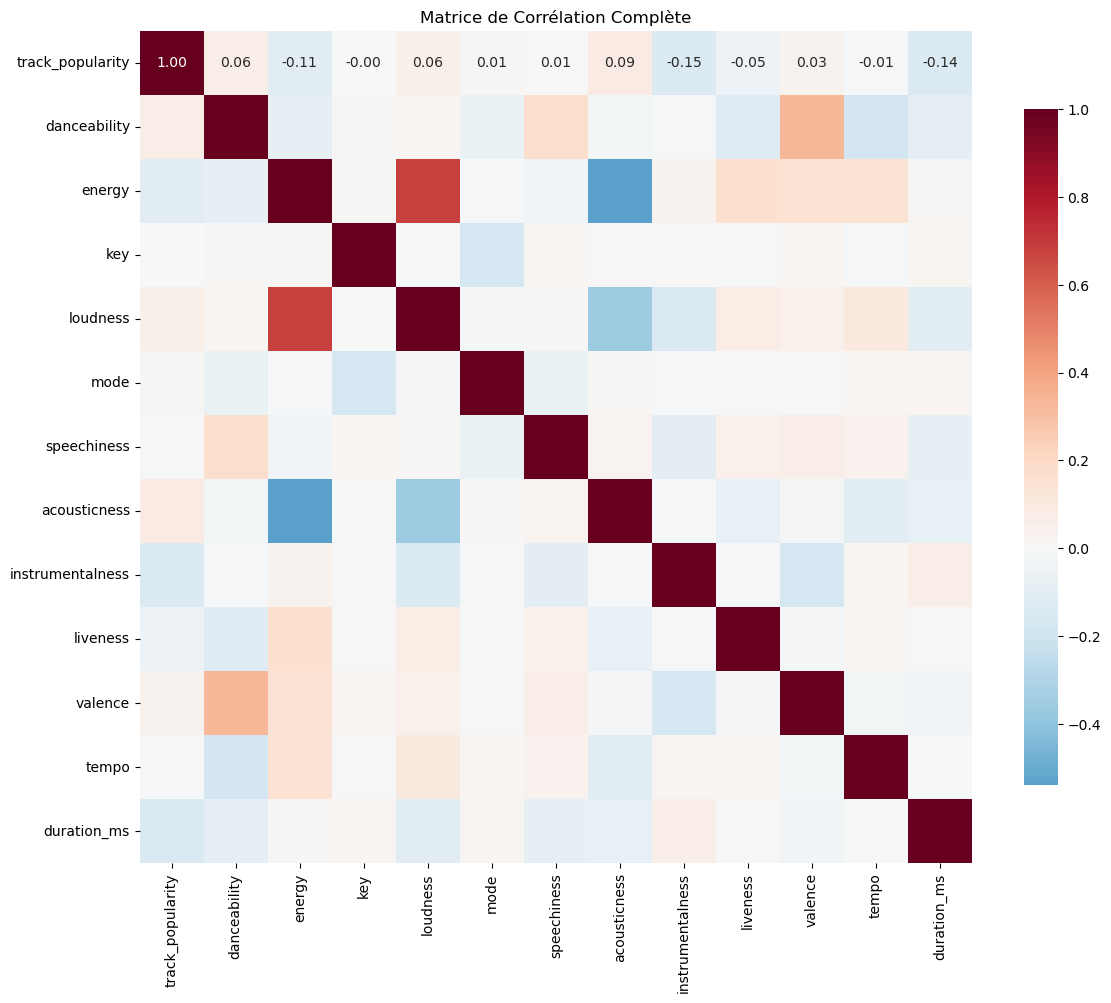

In [ ]:
#ON AFFICHE LE CORRPLOT

cols = ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 
        'speechiness', 'acousticness', 'instrumentalness', 'liveness', 
        'valence', 'tempo', 'duration_ms']

data_num = data[cols].apply(pd.to_numeric, errors='coerce')

# 2. On calcule la matrice
corr_matrix = data_num.corr()

# 3. On force une taille de figure assez haute pour éviter l'écrasement
plt.figure(figsize=(12, 10)) 

# 4. Le Heatmap avec réglages de sécurité
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', # Bleu pour positif, Rouge pour négatif
    center=0,
    square=True,    # Force les cases à être des carrés (évite l'écrasement)
    cbar_kws={"shrink": .8} # Réduit la barre de légende pour laisser de la place
)

# Correction du bug de coupure (parfois le haut et le bas sont coupés sur d'anciennes versions)
plt.ylim(len(corr_matrix), 0) 
plt.title("Matrice de Corrélation Complète")
plt.tight_layout() # Ajuste automatiquement les marges
plt.show()

#On observe de fortes corrélation positives entre :
#loudness/energy
#valence/danceability
#speechiness/danceability
#On observe de fortes corrélation négativess entre :
#energy/acousticness
#loudness/acousticness
#

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

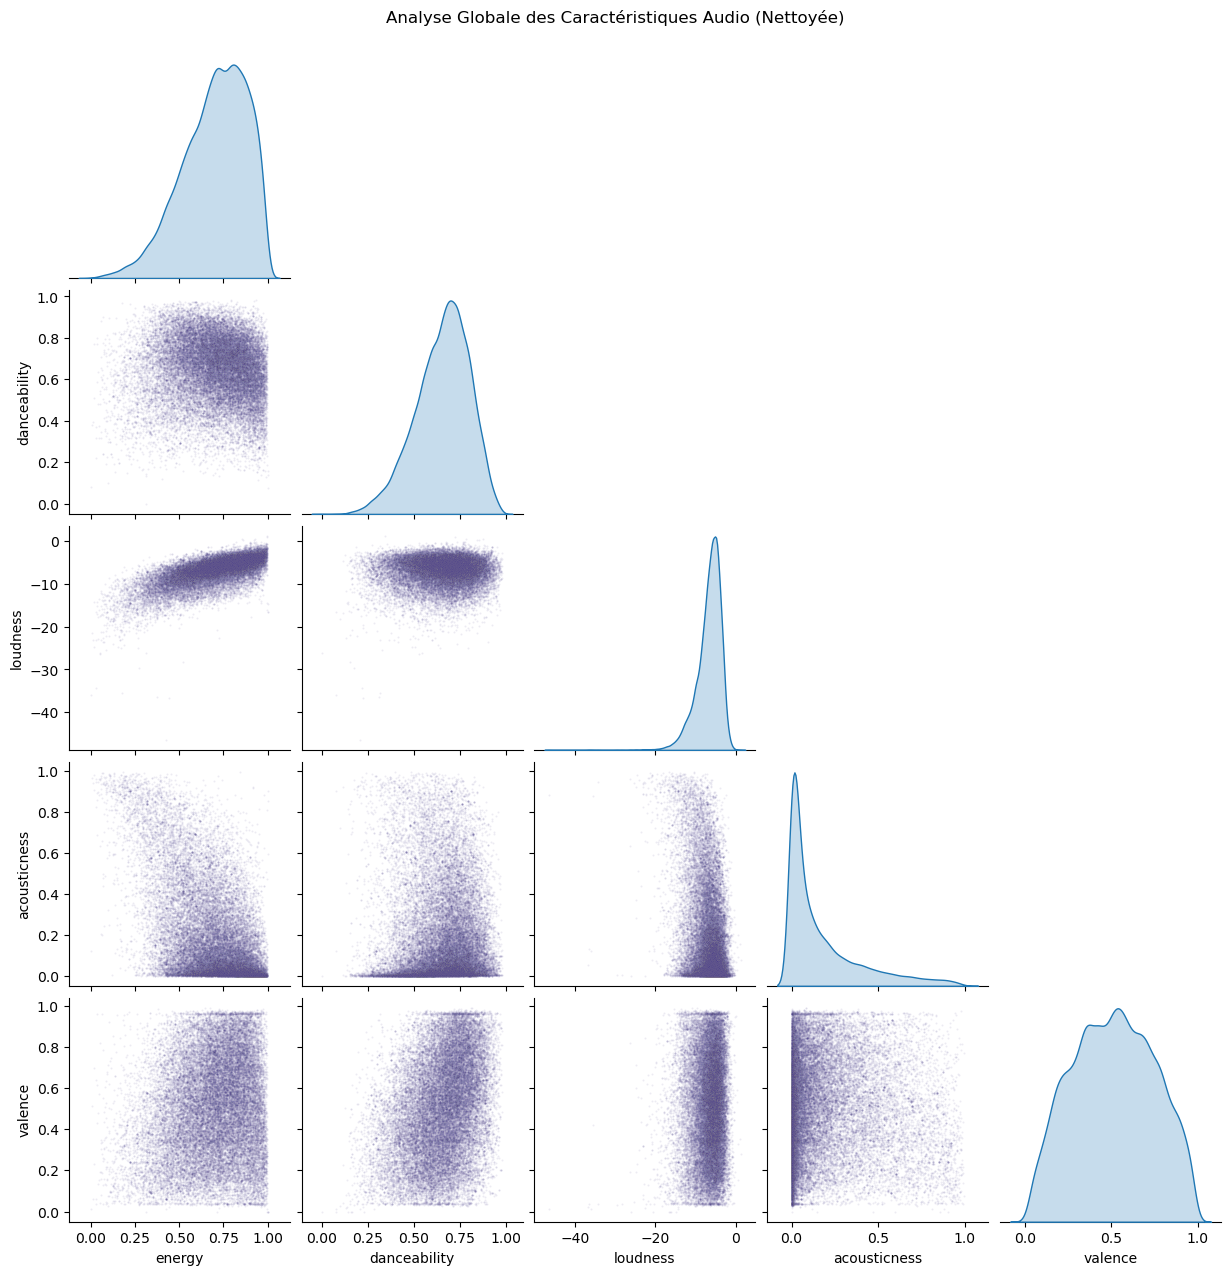

In [ ]:
#ON AFFICHE DES PAIRPLOT POUR DISTRIBUTION ET CORRELATION : AMODIFIER VOIR

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sélectionner les colonnes
cols_audio = ['energy', 'danceability', 'loudness', 'acousticness', 'valence']

# 2. Nettoyage strict pour le graphique

data_plot = data[cols_audio].dropna().astype(float)

# 3. Création du pairplot
sns.pairplot(data_plot, 
             diag_kind='kde', 
             plot_kws={'alpha': 0.1, 's': 2, 'color': 'darkslateblue'}, # Points très petits et transparents
             corner=True)

plt.suptitle("Analyse Globale des Caractéristiques Audio (Nettoyée)", y=1.02)
plt.show()

In [ ]:
#Ines a fait un truc sur les outlyers

# LE reste du tp Human ressources
# est globalement centré 
# sur de la prédiction de variables et 
# très difficilement transposable

In [ ]:
!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 1.4 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 5.4 MB/s eta 0:00:000m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 4.1 MB/s eta 0:00:000m eta 0:00:01


/home/taffet/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


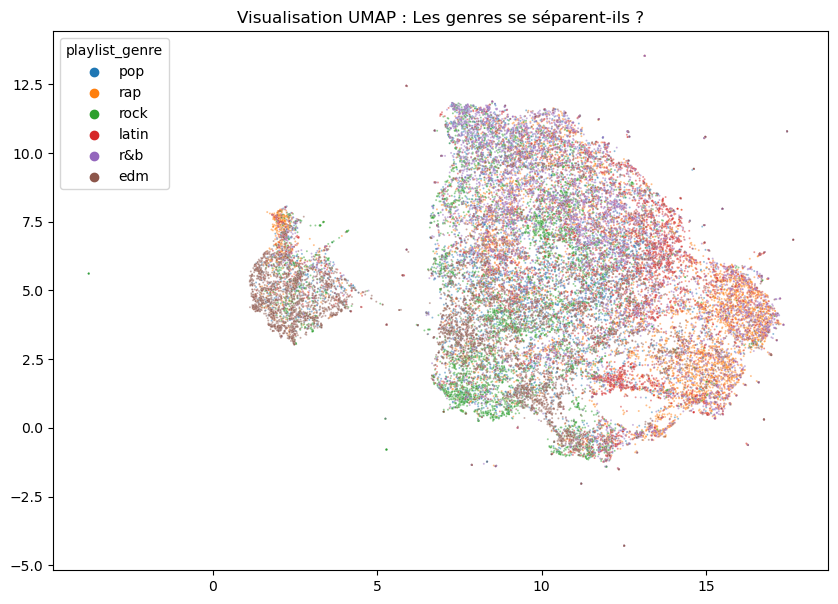

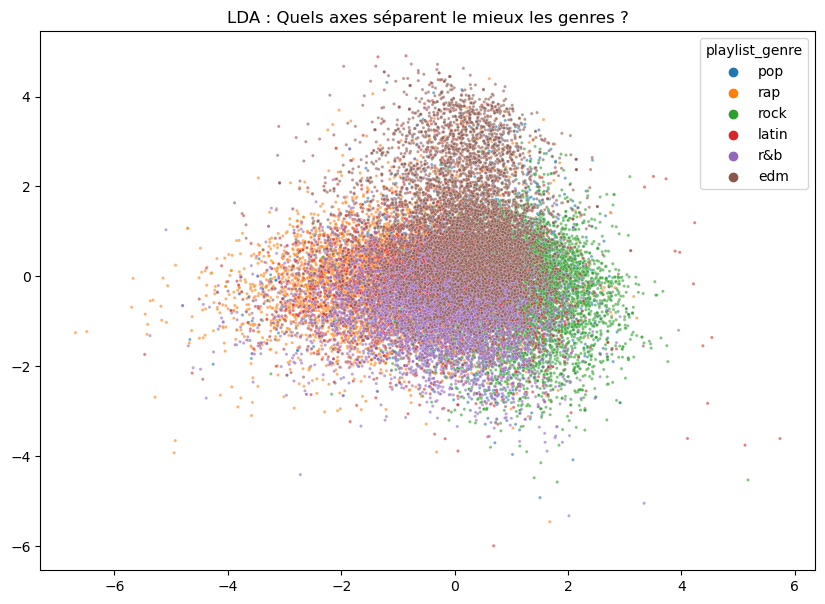

In [ ]:
import umap # pip install umap-learn
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sélection des colonnes (on utilise 'data' et non 'df')
cols_audio = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
              'instrumentalness', 'liveness', 'valence', 'tempo']

# On nettoie les éventuelles valeurs manquantes sur ces colonnes
data_clean = data.dropna(subset=cols_audio)
X = data_clean[cols_audio]
y = data_clean['playlist_genre']

# 2. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#L'UMAP va créer des "îlots". Contrairement à 
# l'ACP qui cherche à étaler la variance, 
# l'UMAP cherche à garder les voisins proches 
# ensemble
# --- UMAP (Réduction non-linéaire) ---
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y, s=2, alpha=0.5)
plt.title("Visualisation UMAP : Les genres se séparent-ils ?")
plt.show()

# --- LDA (Séparation des classes) ---
lda = LinearDiscriminantAnalysis(n_components=5)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, s=5, alpha=0.6)
plt.title("LDA : Quels axes séparent le mieux les genres ?")
plt.show()

/home/taffet/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


TypeError: Cannot interpret 'Int64Dtype()' as a data type

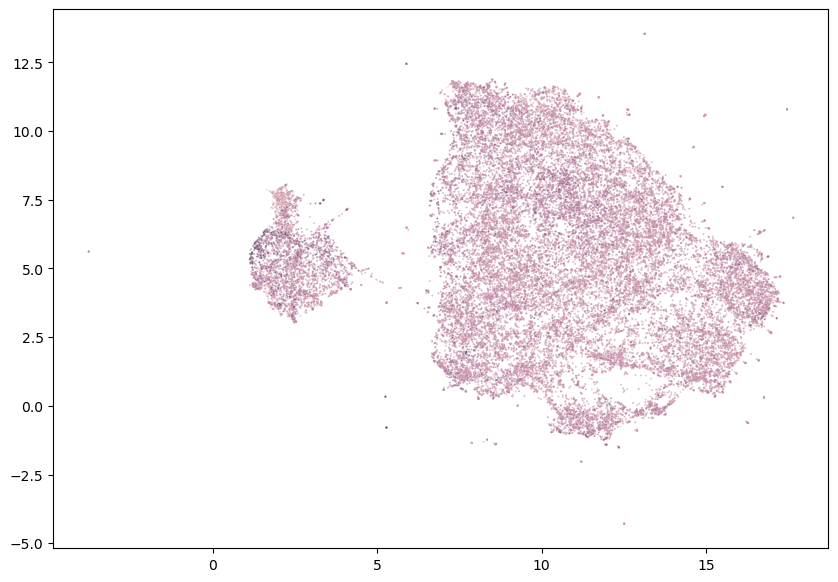

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import umap  # Assurez-vous que umap-learn est installé : pip install umap-learn
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Sélection des colonnes (on utilise 'data' et non 'df')
cols_audio = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
              'instrumentalness', 'liveness', 'valence', 'tempo']

# On nettoie les éventuelles valeurs manquantes sur ces colonnes
data_clean = data.dropna(subset=cols_audio)
X = data_clean[cols_audio]
y = data_clean['duration_ms']

# 2. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#L'UMAP va créer des "îlots". Contrairement à 
# l'ACP qui cherche à étaler la variance, 
# l'UMAP cherche à garder les voisins proches 
# ensemble
# --- UMAP (Réduction non-linéaire) ---
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y, s=2, alpha=0.5)
plt.title("Visualisation UMAP : Les genres se séparent-ils ?")
plt.show()

# --- LDA (Séparation des classes) ---
lda = LinearDiscriminantAnalysis(n_components=5)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, s=5, alpha=0.6)
plt.title("LDA : Quels axes séparent le mieux les genres ?")
plt.show()

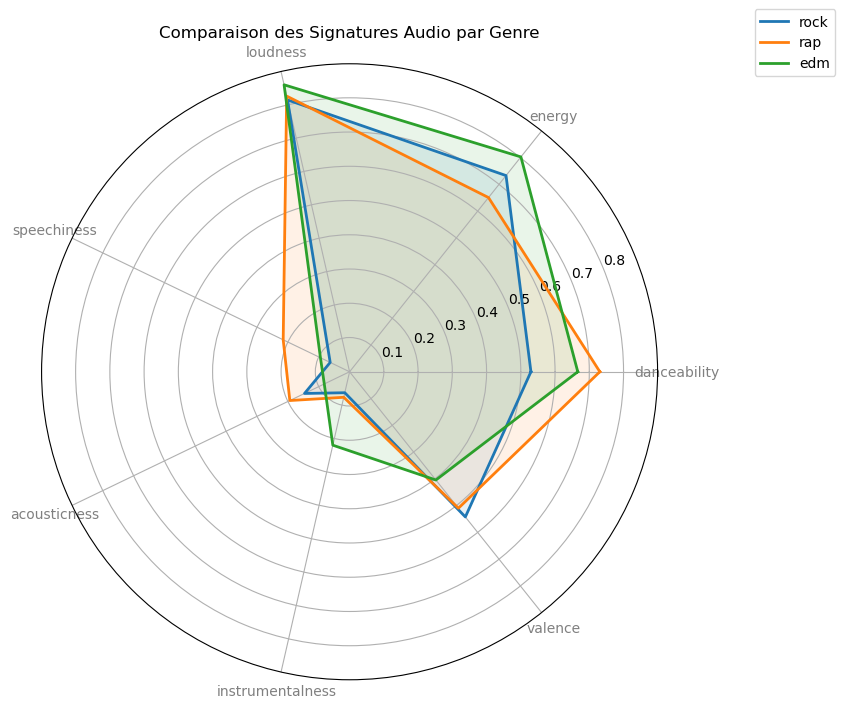

In [ ]:
import numpy as np
from math import pi

# 1. Sélection des colonnes et normalisation (Min-Max) pour que tout soit entre 0 et 1
cols_radar = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence']
df_radar = data_clean[cols_radar + ['playlist_genre']].copy()

# Normalisation pour le graphique
for col in cols_radar:
    df_radar[col] = (df_radar[col] - df_radar[col].min()) / (df_radar[col].max() - df_radar[col].min())

# Moyenne par genre
stats = df_radar.groupby('playlist_genre').mean()

def make_radar(genres_list, data_stats):
    categories = list(data_stats.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for genre in genres_list:
        # Utilisation de .to_numpy() pour éviter le bug FloatingArray
        values = data_stats.loc[genre].to_numpy().flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=genre)
        ax.fill(angles, values, alpha=0.1)
    
    plt.xticks(angles[:-1], categories, color='grey', size=10)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title("Comparaison des Signatures Audio par Genre")
    plt.show()

# Affichage : tu peux changer les genres dans la liste
make_radar(['rock', 'rap', 'edm'], stats)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

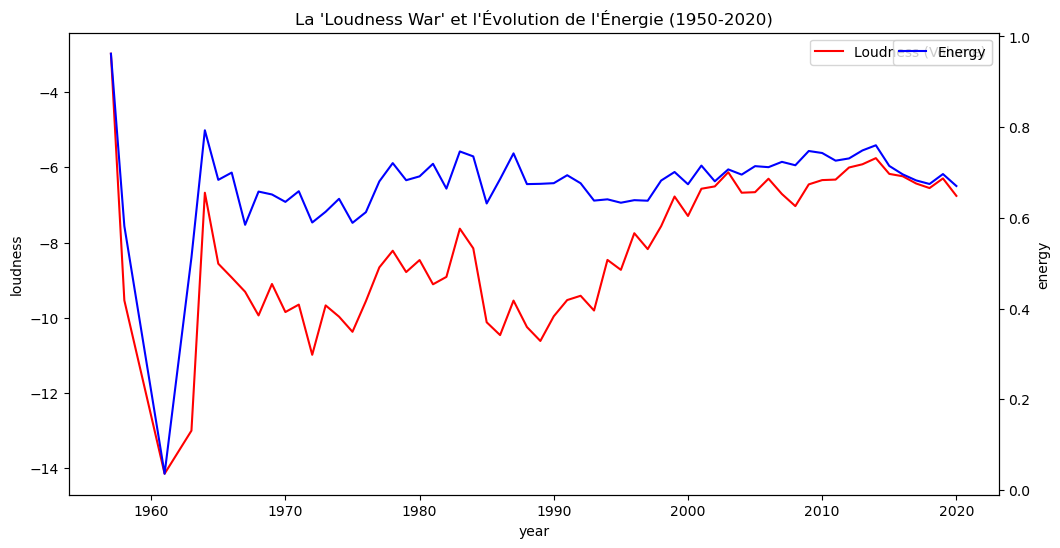

In [ ]:
# 1. Extraction propre de l'année
# On s'assure que c'est bien du texte avant le split pour éviter les erreurs de type
data_clean['year'] = data_clean['track_album_release_date'].astype(str).str[:4]
data_clean['year'] = pd.to_numeric(data_clean['year'], errors='coerce')

# 2. Filtrer les années aberrantes (si besoin, ex: avant 1950)
df_temporel = data_clean[data_clean['year'] > 1950]

# 3. Calcul de la moyenne annuelle
# On reconvertit en float standard pour éviter les soucis de FloatingArray avec Seaborn
evolution = df_temporel.groupby('year')[['loudness', 'energy', 'danceability']].mean().astype(float)

# 4. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=evolution['loudness'], color='red', label='Loudness (Volume)')
plt.twinx() # Créer un deuxième axe Y pour l'énergie car les échelles diffèrent
sns.lineplot(data=evolution['energy'], color='blue', label='Energy')

plt.title("La 'Loudness War' et l'Évolution de l'Énergie (1950-2020)")
plt.xlabel("Année de sortie")
plt.show()

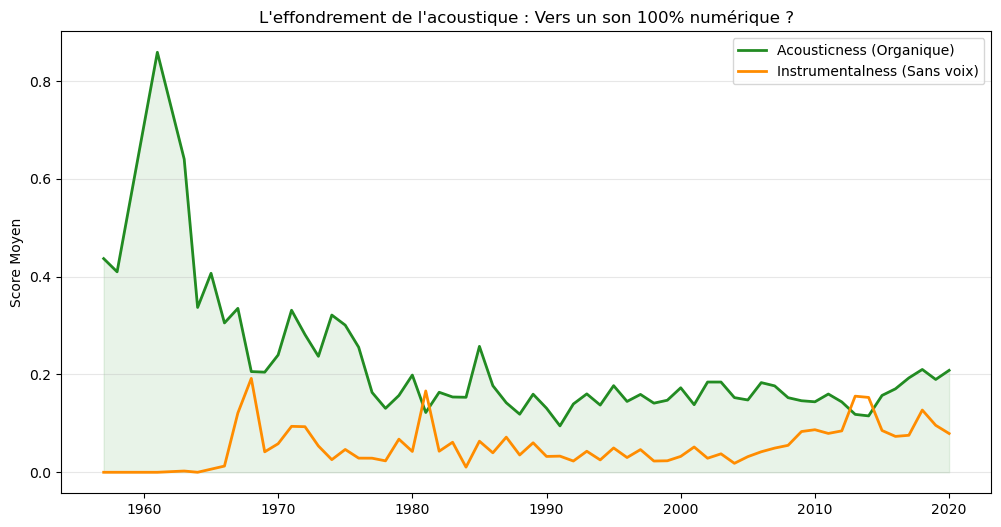

In [ ]:
# On prépare les données (en s'assurant que ce sont des floats)
evo_organic = df_temporel.groupby('year')[['acousticness', 'instrumentalness', 'speechiness']].mean().astype(float)

plt.figure(figsize=(12, 6))
plt.plot(evo_organic.index, evo_organic['acousticness'], label='Acousticness (Organique)', color='forestgreen', lw=2)
plt.plot(evo_organic.index, evo_organic['instrumentalness'], label='Instrumentalness (Sans voix)', color='darkorange', lw=2)
plt.fill_between(evo_organic.index, evo_organic['acousticness'], alpha=0.1, color='forestgreen')

plt.title("L'effondrement de l'acoustique : Vers un son 100% numérique ?")
plt.ylabel("Score Moyen")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

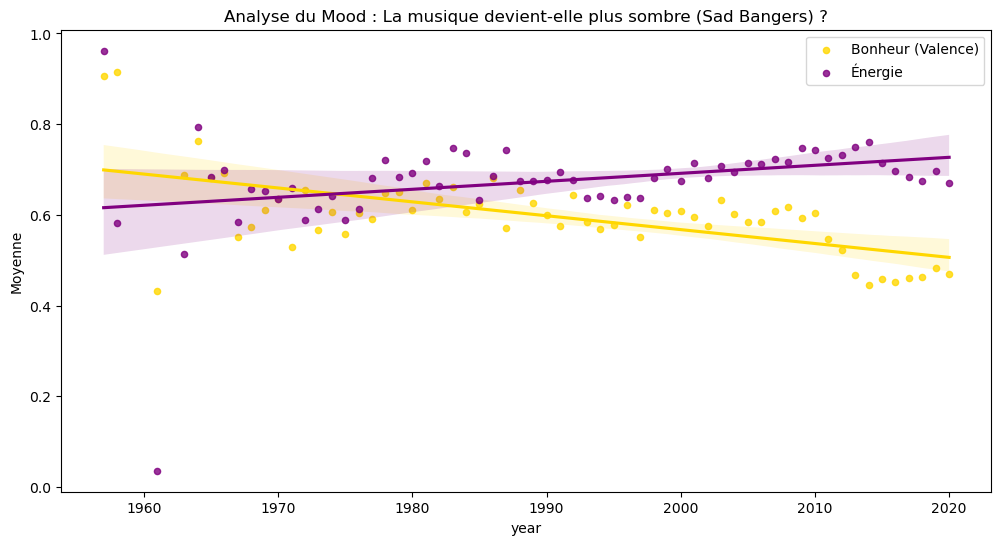

In [ ]:
# Calcul du ratio
evo_mood = df_temporel.groupby('year')[['valence', 'energy']].mean().astype(float)

plt.figure(figsize=(12, 6))
sns.regplot(x=evo_mood.index, y=evo_mood['valence'], scatter_kws={'s':20}, label='Bonheur (Valence)', color='gold')
sns.regplot(x=evo_mood.index, y=evo_mood['energy'], scatter_kws={'s':20}, label='Énergie', color='purple')

plt.title("Analyse du Mood : La musique devient-elle plus sombre (Sad Bangers) ?")
plt.ylabel("Moyenne")
plt.legend()
plt.show()

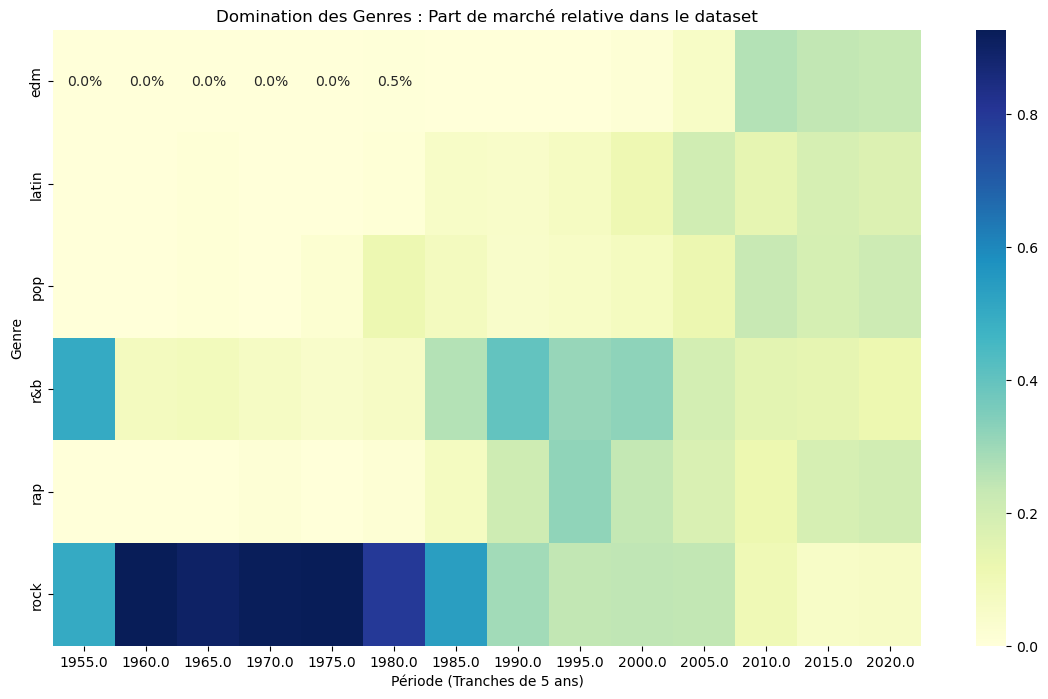

In [ ]:
# 1. Création de tranches de 5 ans pour plus de clarté
data_clean['period'] = (data_clean['year'] // 5) * 5

# 2. On compte le nombre de chansons par genre et par période
genre_trend = data_clean.groupby(['period', 'playlist_genre']).size().unstack().fillna(0)

# 3. Normalisation par ligne (pour voir la part de marché relative)
genre_trend_pct = genre_trend.div(genre_trend.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(genre_trend_pct.T, annot=True, fmt=".1%", cmap="YlGnBu")
plt.title("Domination des Genres : Part de marché relative dans le dataset")
plt.ylabel("Genre")
plt.xlabel("Période (Tranches de 5 ans)")
plt.show()

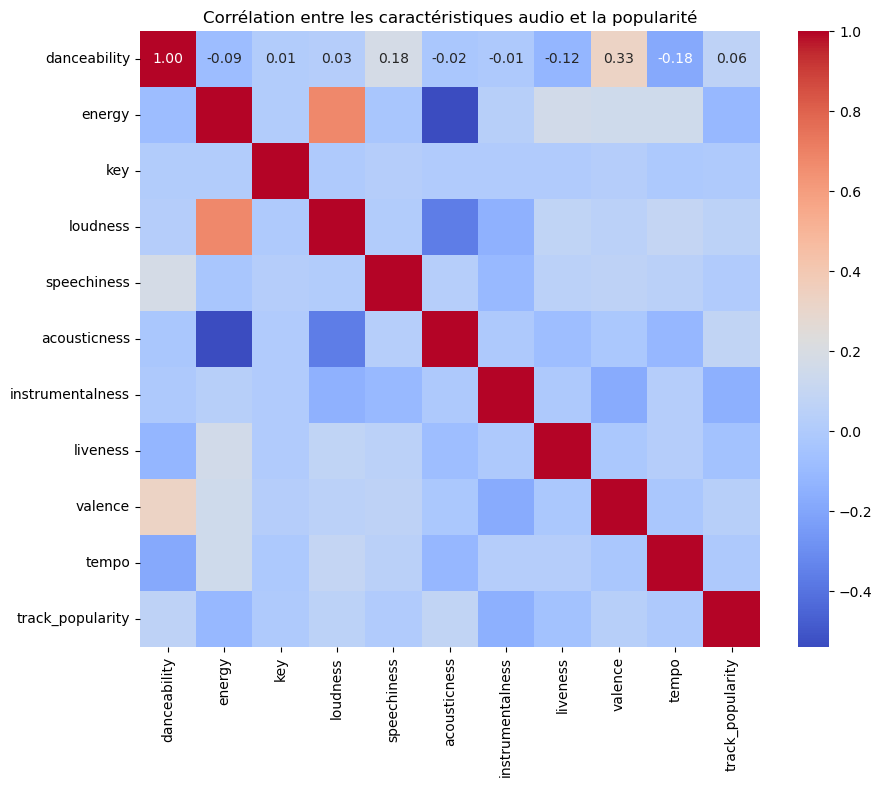

In [ ]:
# Conversion de la date et extraction de l'année
data['track_album_release_date'] = pd.to_datetime(data['track_album_release_date'], errors='coerce')
data['release_year'] = data['track_album_release_date'].dt.year

# Matrice de corrélation des caractéristiques audio
audio_features = ['danceability', 'energy', 'key', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_popularity']
plt.figure(figsize=(10, 8))
sns.heatmap(data[audio_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation entre les caractéristiques audio et la popularité")
plt.show()

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.5/179.5 kB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 5.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 6.33.5 which is incompatible.


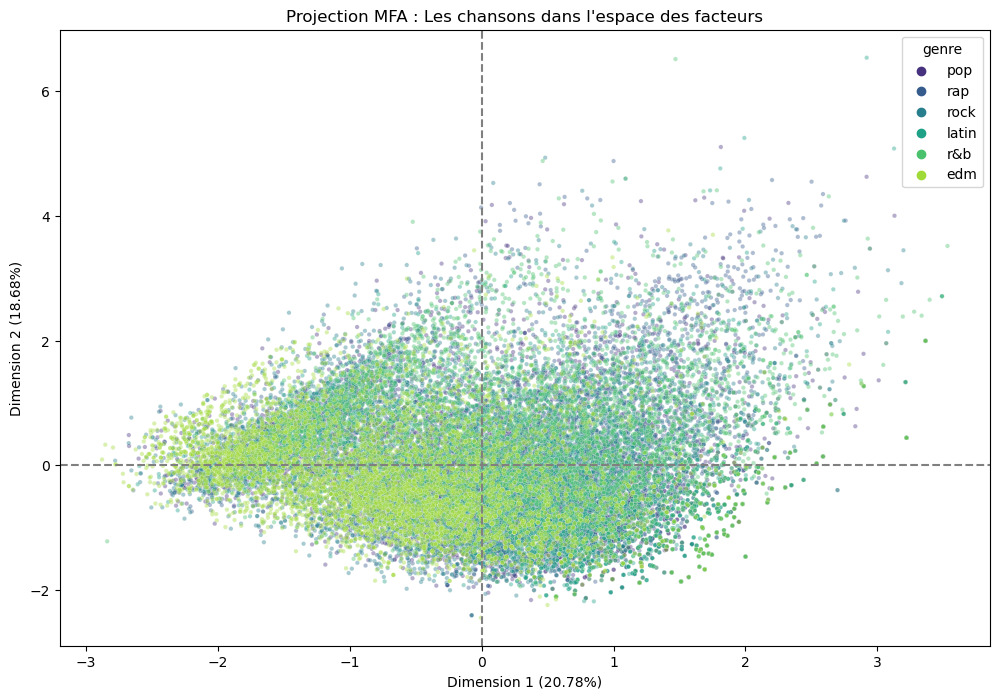

TypeError: 'DataFrame' object is not callable

In [ ]:
!pip install prince

import prince
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des colonnes
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo']
target_feature = ['track_popularity']

# On crée le dataset pour la MFA (uniquement le numérique)
X_mfa = data_clean[audio_features + target_feature].copy()

# 2. Définition des groupes
# On sépare les caractéristiques "sonores" du "succès"
groups = {
    'Audio': audio_features,
    'Performance': target_feature
}

# 3. Fit de la MFA
mfa = prince.MFA(n_components=2, n_iter=3, random_state=42)
mfa = mfa.fit(X_mfa, groups=groups)

# 4. Visualisation des Individus (colorés par genre)
row_coords = mfa.row_coordinates(X_mfa)
row_coords['genre'] = data_clean['playlist_genre']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=row_coords, x=0, y=1, hue='genre', 
    alpha=0.4, s=10, palette='viridis'
)
plt.title("Projection MFA : Les chansons dans l'espace des facteurs")
plt.xlabel(f"Dimension 1 ({mfa.eigenvalues_summary.iloc[0, 1]})")
plt.ylabel(f"Dimension 2 ({mfa.eigenvalues_summary.iloc[1, 1]})")
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.show()

# 5. Visualisation des Variables (Cercle des corrélations)
# Cela remplace 'plot_group_contributions'
col_corr = mfa.column_correlations(X_mfa)
plt.figure(figsize=(10, 10))
for i, (var, coords) in enumerate(col_corr.iterrows()):
    plt.arrow(0, 0, coords[0], coords[1], head_width=0.03, head_length=0.03, color='red', alpha=0.6)
    plt.text(coords[0]*1.1, coords[1]*1.1, var, fontsize=11)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title("Cercle des corrélations (MFA)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid()
plt.show()

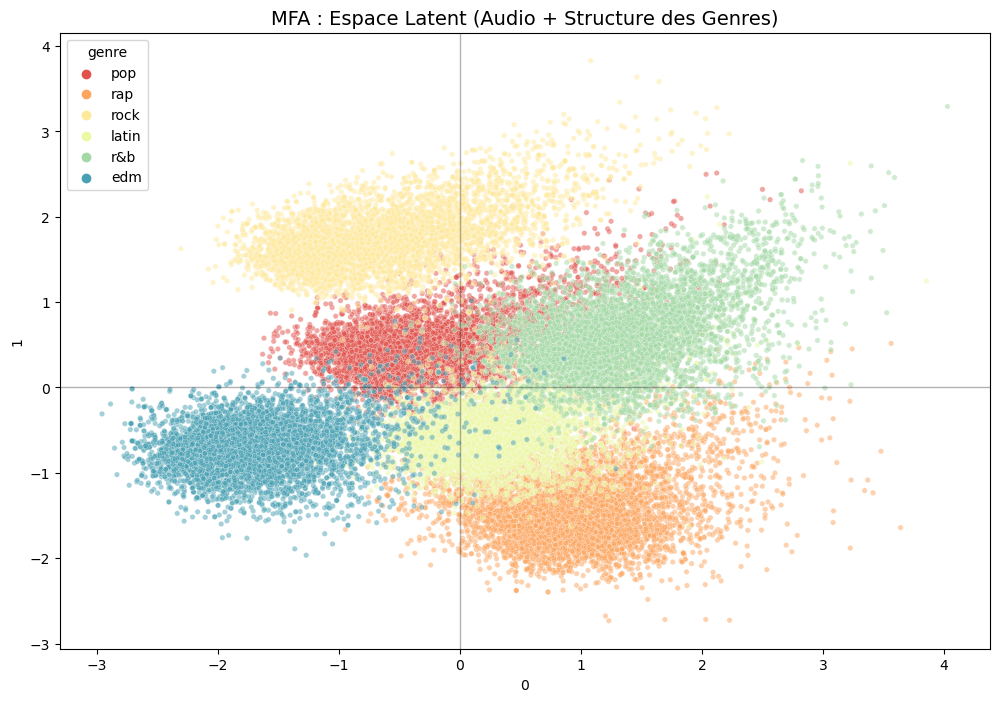

In [ ]:
import prince
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des données
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo']

# Création des variables "dummies" pour le genre (0 ou 1)
genre_dummies = pd.get_dummies(data_clean['playlist_genre'], prefix='genre')
genre_cols = genre_dummies.columns.tolist()

# On assemble le tout : Audio + Genres encodés
X_mfa = pd.concat([data_clean[audio_features].astype(float), genre_dummies], axis=1)

# 2. Définition des groupes (tous numériques maintenant)
groups = {
    'Audio': audio_features,
    'Genre_Struct': genre_cols
}

# 3. Fit de la MFA
mfa = prince.MFA(n_components=2, n_iter=3, random_state=42)
mfa = mfa.fit(X_mfa, groups=groups)

# 4. Visualisation
row_coords = mfa.row_coordinates(X_mfa)
row_coords['genre'] = data_clean['playlist_genre'].values

plt.figure(figsize=(12, 8))
sns.scatterplot(data=row_coords, x=0, y=1, hue='genre', alpha=0.5, s=15, palette='Spectral')

plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)
plt.title("MFA : Espace Latent (Audio + Structure des Genres)", fontsize=14)
plt.show()

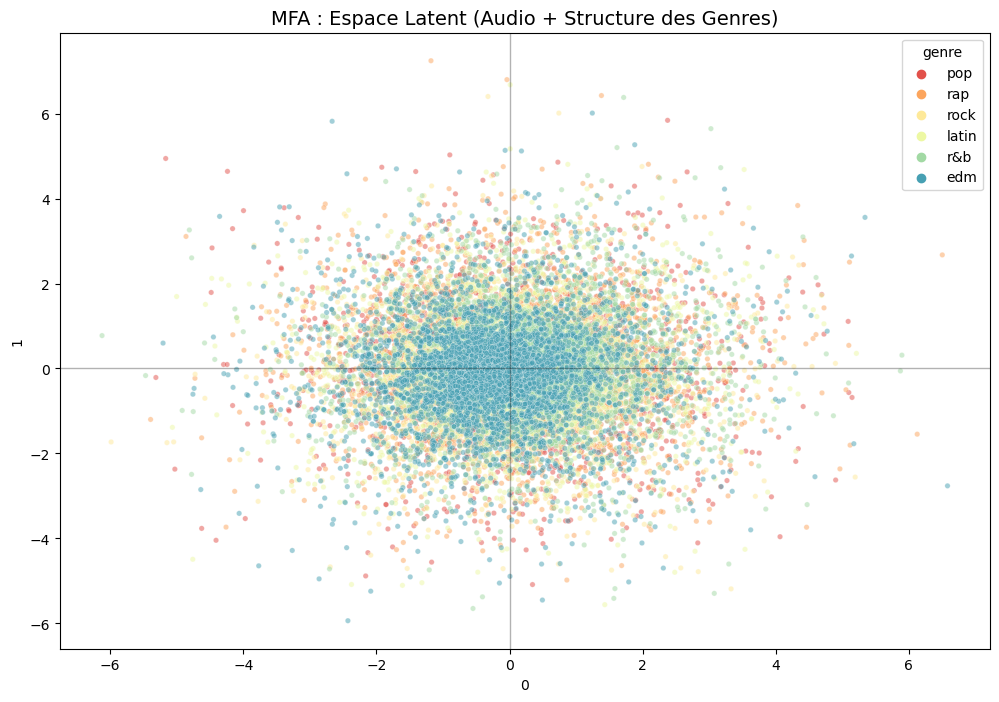

In [ ]:
import prince
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des données
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo']

# Création des variables "dummies" pour le genre (0 ou 1)
genre_dummies = pd.get_dummies(data_clean['track_artist'], prefix='artiste')
genre_cols = genre_dummies.columns.tolist()

# On assemble le tout : Audio + Genres encodés
X_mfa = pd.concat([data_clean[audio_features].astype(float), genre_dummies], axis=1)

# 2. Définition des groupes (tous numériques maintenant)
groups = {
    'Audio': audio_features,
    'Genre_Struct': genre_cols
}

# 3. Fit de la MFA
mfa = prince.MFA(n_components=2, n_iter=3, random_state=42)
mfa = mfa.fit(X_mfa, groups=groups)

# 4. Visualisation
row_coords = mfa.row_coordinates(X_mfa)
row_coords['genre'] = data_clean['playlist_genre'].values

plt.figure(figsize=(12, 8))
sns.scatterplot(data=row_coords, x=0, y=1, hue='genre', alpha=0.5, s=15, palette='Spectral')

plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)
plt.title("MFA : Espace Latent (Audio + Structure des Genres)", fontsize=14)
plt.show()

Recherche du meilleur K (échantillon de 5000 points)...
K=2 -> Score Silhouette: 0.251
K=3 -> Score Silhouette: 0.357
K=4 -> Score Silhouette: 0.471
K=5 -> Score Silhouette: 0.597
K=6 -> Score Silhouette: 0.696

=> Meilleur K retenu : 6


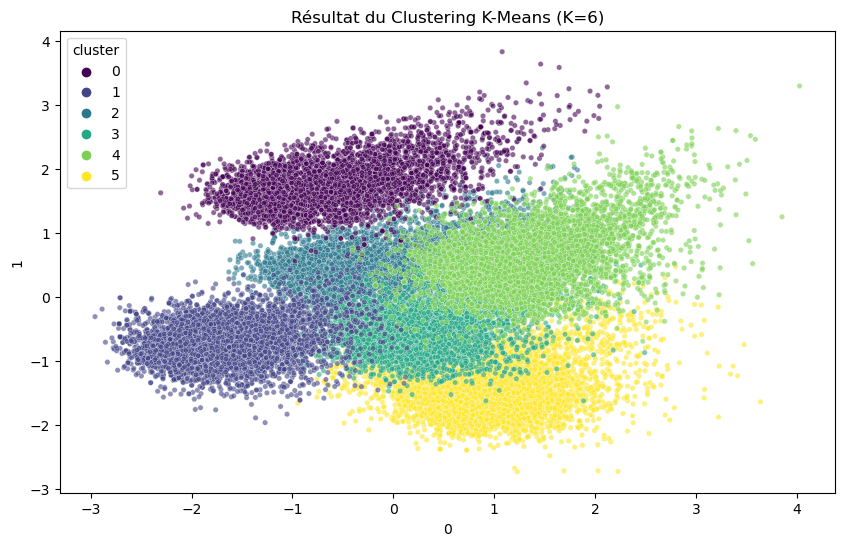


--- Profil technique des clusters (Moyennes) ---


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.520,0.733,-7.596,0.058,0.145,0.063,0.204,0.537,125.004
1,0.655,0.806,-5.365,0.086,0.077,0.219,0.213,0.401,125.900
2,0.640,0.702,-6.288,0.074,0.169,0.059,0.177,0.504,120.778
3,0.716,0.712,-6.146,0.103,0.207,0.042,0.180,0.609,118.622
4,0.669,0.584,-8.051,0.116,0.270,0.034,0.174,0.527,114.117
5,0.719,0.652,-7.016,0.198,0.191,0.075,0.192,0.505,120.722


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# 1. Préparation des données
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 
                  'instrumentalness', 'liveness', 'valence', 'tempo']

# Utilisation des genres pour la structure MFA
genre_dummies = pd.get_dummies(data_clean['playlist_genre'], prefix='genre')
genre_cols = genre_dummies.columns.tolist()
X_mfa = pd.concat([data_clean[audio_features].astype(float), genre_dummies], axis=1)

groups = {
    'Audio': audio_features,
    'Genre': genre_cols
}

# 2. MFA : On sépare FIT et TRANSFORM pour éviter le TypeError
mfa = prince.MFA(n_components=5, n_iter=3, random_state=42)
mfa.fit(X_mfa, groups=groups)  # L'argument groups va ici
X_mfa_coords = mfa.transform(X_mfa) # Puis on transforme

# 3. Recherche du nombre de clusters (K) optimal
sil_scores = []
k_range = range(2, 7)

# On échantillonne pour accélérer le calcul de la silhouette si besoin
sample_size = min(5000, len(X_mfa_coords))
X_sample = X_mfa_coords.sample(sample_size, random_state=42)

print(f"Recherche du meilleur K (échantillon de {sample_size} points)...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_mfa_coords)
    # On calcule le score sur l'échantillon pour la rapidité
    score = silhouette_score(X_mfa_coords, labels, sample_size=sample_size)
    sil_scores.append(score)
    print(f"K={k} -> Score Silhouette: {score:.3f}")

# 4. Clustering final
best_k = k_range[np.argmax(sil_scores)]
print(f"\n=> Meilleur K retenu : {best_k}")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data_clean['cluster'] = kmeans.fit_predict(X_mfa_coords)

# 5. Visualisation des clusters dans l'espace MFA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_mfa_coords.iloc[:, 0], 
    y=X_mfa_coords.iloc[:, 1], 
    hue=data_clean['cluster'], 
    palette='viridis', s=15, alpha=0.6
)
plt.title(f"Résultat du Clustering K-Means (K={best_k})")
plt.show()

# 6. Tableau des chiffres uniquement (Profil moyen par cluster)
print("\n--- Profil technique des clusters (Moyennes) ---")

# Calcul de la moyenne des caractéristiques audio pour chaque cluster
profil = data_clean.groupby('cluster')[audio_features].mean()

# Affichage stylisé avec dégradé de couleur
display(profil.style.background_gradient(cmap='YlGnBu', axis=0).format("{:.3f}"))

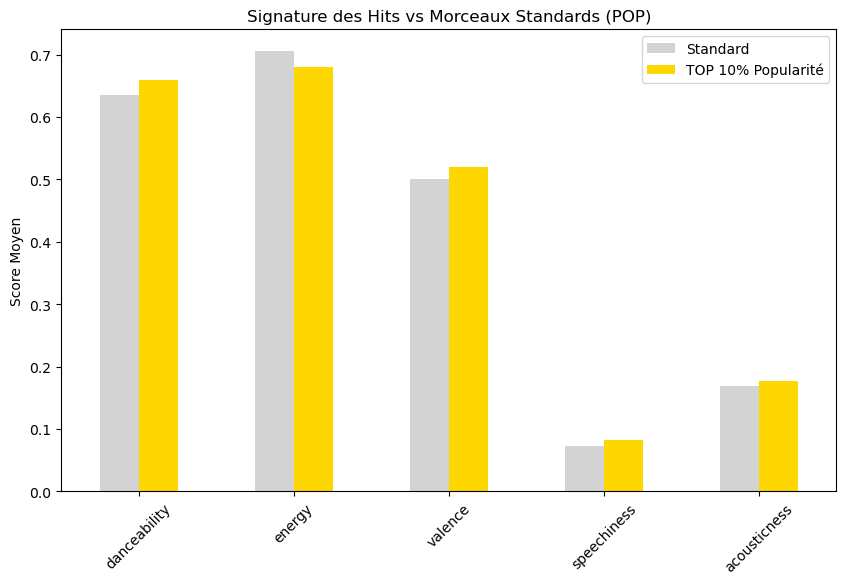

In [ ]:
# On définit les "Hits" (Top 10% de popularité)
threshold = data_clean['track_popularity'].quantile(0.9)
data_clean['is_hit'] = data_clean['track_popularity'] >= threshold

# On choisit un genre, par exemple 'pop' ou 'rap'
genre_test = 'pop'
subset = data_clean[data_clean['playlist_genre'] == genre_test]

# Comparaison des moyennes
features = ['danceability', 'energy', 'valence', 'speechiness', 'acousticness']
comparison = subset.groupby('is_hit')[features].mean().astype(float)

# Plot en barres miroir ou superposées
comparison.T.plot(kind='bar', figsize=(10, 6), color=['lightgrey', 'gold'])
plt.title(f"Signature des Hits vs Morceaux Standards ({genre_test.upper()})")
plt.ylabel("Score Moyen")
plt.xticks(rotation=45)
plt.legend(['Standard', 'TOP 10% Popularité'])
plt.show()

# ANALYSE : Si les barres jaunes sont plus hautes en 'danceability', 
# tu as prouvé que la popularité est liée à la danse dans ce genre !

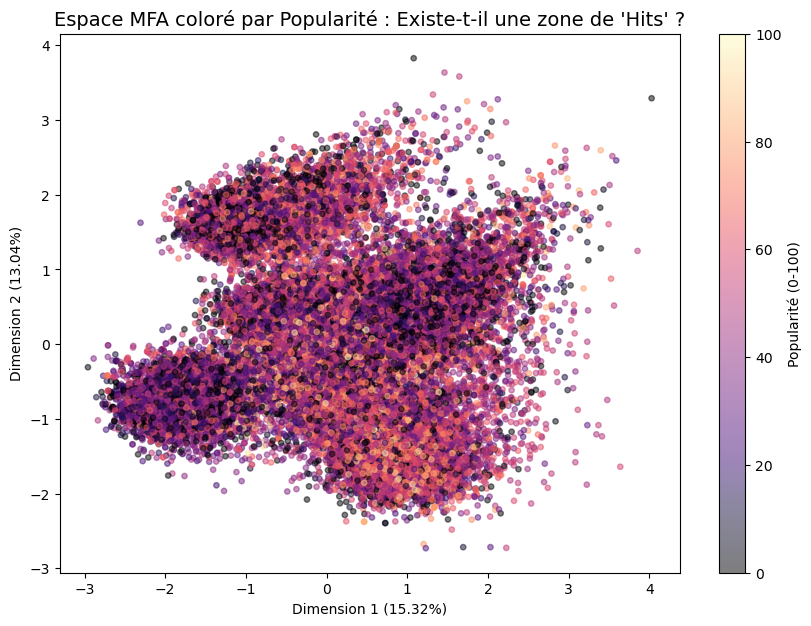

In [ ]:
# On récupère les coordonnées des morceaux sur les axes de la MFA
row_coords = mfa.row_coordinates(X_mfa)

# On ajoute la popularité (attention au nom de la colonne : track_popularity)
# On utilise .values pour s'assurer que l'index correspond
row_coords['track_popularity'] = data_clean['track_popularity'].values

plt.figure(figsize=(10, 7))
# On utilise un dégradé 'Viridis' ou 'Magma' pour la popularité
sc = plt.scatter(row_coords[0], row_coords[1], 
                 c=row_coords['track_popularity'], 
                 cmap='magma', alpha=0.5, s=15)

plt.colorbar(sc, label='Popularité (0-100)')
plt.title("Espace MFA coloré par Popularité : Existe-t-il une zone de 'Hits' ?", fontsize=14)
plt.xlabel(f"Dimension 1 ({mfa.eigenvalues_summary.iloc[0, 1]})")
plt.ylabel(f"Dimension 2 ({mfa.eigenvalues_summary.iloc[1, 1]})")
plt.show()

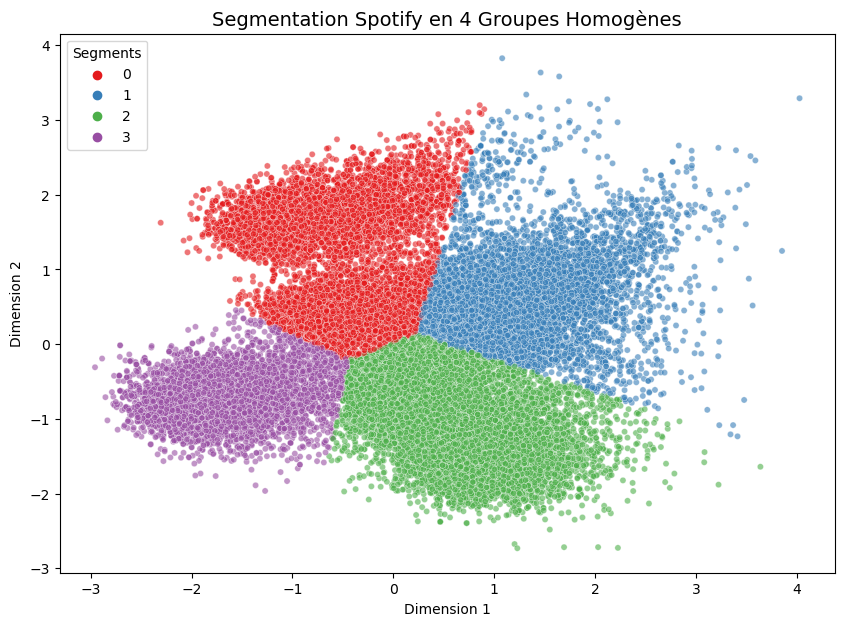

In [ ]:
from sklearn.cluster import KMeans

# 1. Clustering sur les coordonnées MFA (3 ou 4 groupes)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
row_coords['cluster'] = kmeans.fit_predict(mfa.row_coordinates(X_mfa))

# 2. Visualisation des clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(data=row_coords, x=0, y=1, hue='cluster', 
                palette='Set1', s=20, alpha=0.6)

plt.title(f"Segmentation Spotify en {n_clusters} Groupes Homogènes", fontsize=14)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Segments")
plt.show()

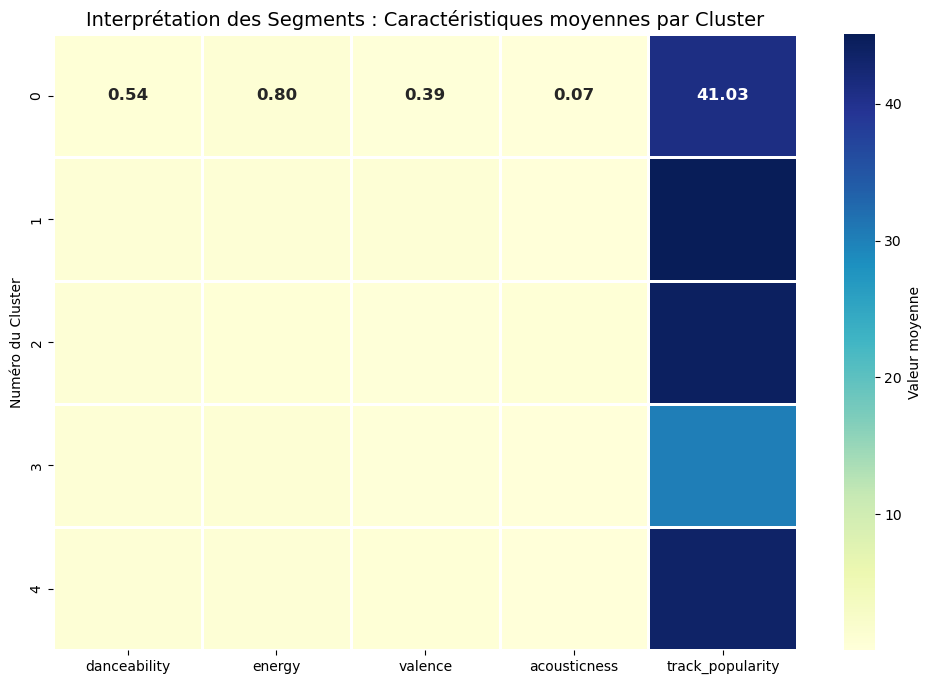

,danceability,energy,valence,acousticness,track_popularity
cluster,,,,,
0,0.54,0.80,0.39,0.07,41.03
1,0.74,0.72,0.67,0.14,45.09
2,0.60,0.43,0.39,0.51,44.32
3,0.66,0.78,0.39,0.08,30.16
4,0.72,0.67,0.55,0.18,43.63


In [ ]:

# 1. On s'assure que les colonnes sont bien numériques (on force le type float)
features_to_compare = ['danceability', 'energy', 'valence', 'acousticness', 'track_popularity']

# 2. Calcul des moyennes par cluster
# On ajoute .astype(float) pour convertir les types "objet/Pandas" en "float standard"
cluster_profile = data.groupby('cluster')[features_to_compare].mean().astype(float)

# 3. Affichage de la Heatmap avec réglages de lisibilité
plt.figure(figsize=(12, 8)) # On agrandit un peu la zone

sns.heatmap(
    cluster_profile, 
    annot=True,            # Affiche les valeurs
    fmt=".2f",             # 2 chiffres après la virgule
    cmap="YlGnBu",        
    linewidths=1,          # Augmente l'espace entre les cases
    annot_kws={"size": 12, "weight": "bold"}, # FORCE la taille et le gras du texte
    cbar_kws={'label': 'Valeur moyenne'}
)

plt.title("Interprétation des Segments : Caractéristiques moyennes par Cluster", fontsize=14)
plt.ylabel("Numéro du Cluster")
plt.show()

# 1. Sélection des colonnes
features = ['danceability', 'energy', 'valence', 'acousticness', 'track_popularity']

# 2. Calcul des moyennes par cluster
# On arrondit à 2 décimales pour la clarté
cluster_profile = data.groupby('cluster')[features].mean()

# 3. Affichage du tableau stylisé
# On ajoute une barre de couleur directement dans les cases pour comparer les valeurs
display(cluster_profile.style\
    .format("{:.2f}")\
    .background_gradient(cmap="YlGnBu", axis=0)\
    .set_caption("Moyennes des caractéristiques par Cluster"))

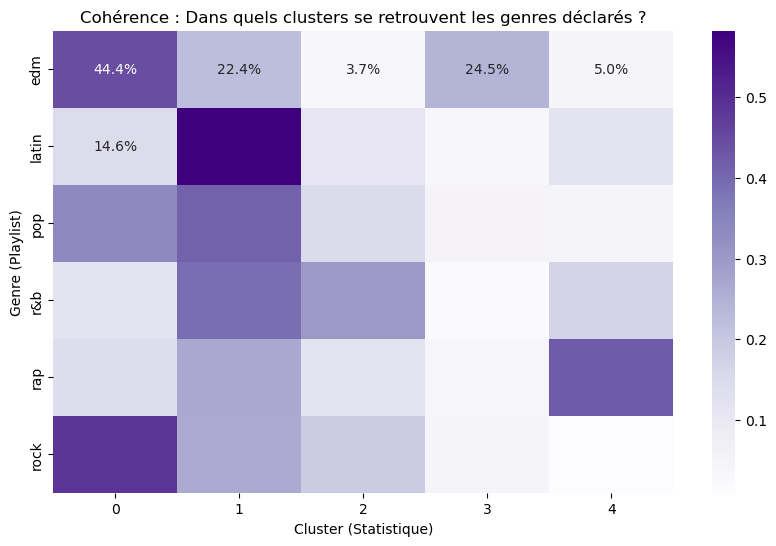

cluster,0,1,2,3,4
playlist_genre,,,,,
edm,44.4%,22.4%,3.7%,24.5%,5.0%
latin,14.6%,58.3%,11.2%,3.8%,12.1%
pop,33.6%,41.4%,15.0%,5.2%,4.8%
r&b,12.1%,39.1%,29.9%,1.9%,17.0%
rap,14.0%,26.9%,12.2%,4.3%,42.5%
rock,48.9%,26.3%,19.0%,4.8%,1.0%


In [ ]:

# 1. Calcul du tableau croisé
ct = pd.crosstab(data['playlist_genre'], data['cluster'], normalize='index')

# 2. On multiplie par 100 pour avoir des pourcentages lisibles et on arrondit
ct_digits = (ct * 100).round(1)

# 3. Affichage stylisé (dans Jupyter, cela affiche un joli tableau)
display(ct_digits.style.format("{:.1f}%").background_gradient(cmap='Purples', axis=1))

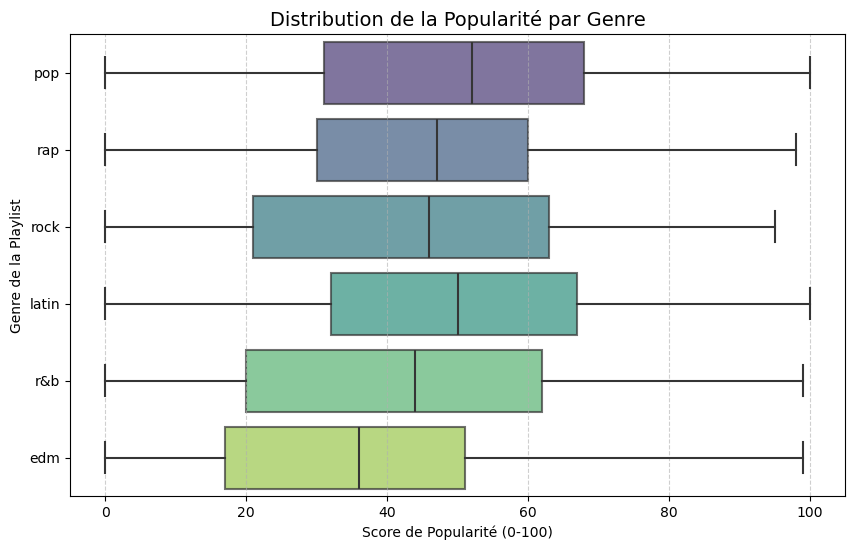

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# On prépare les données en forçant les types
plot_data = data_clean[['playlist_genre', 'track_popularity']].copy()
plot_data['track_popularity'] = plot_data['track_popularity'].astype(float)

plt.figure(figsize=(10, 6))
# Boxplot horizontal pour voir la distribution par genre
sns.boxplot(
    data=plot_data, 
    x='track_popularity', 
    y='playlist_genre', 
    palette='viridis',
    boxprops=dict(alpha=.7)
)

plt.title("Distribution de la Popularité par Genre", fontsize=14)
plt.xlabel("Score de Popularité (0-100)")
plt.ylabel("Genre de la Playlist")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_5570/3377885442.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=subset['energy'], y=subset['valence'], label=g, shade=True, alpha=0.3)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_5570/3377885442.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update you

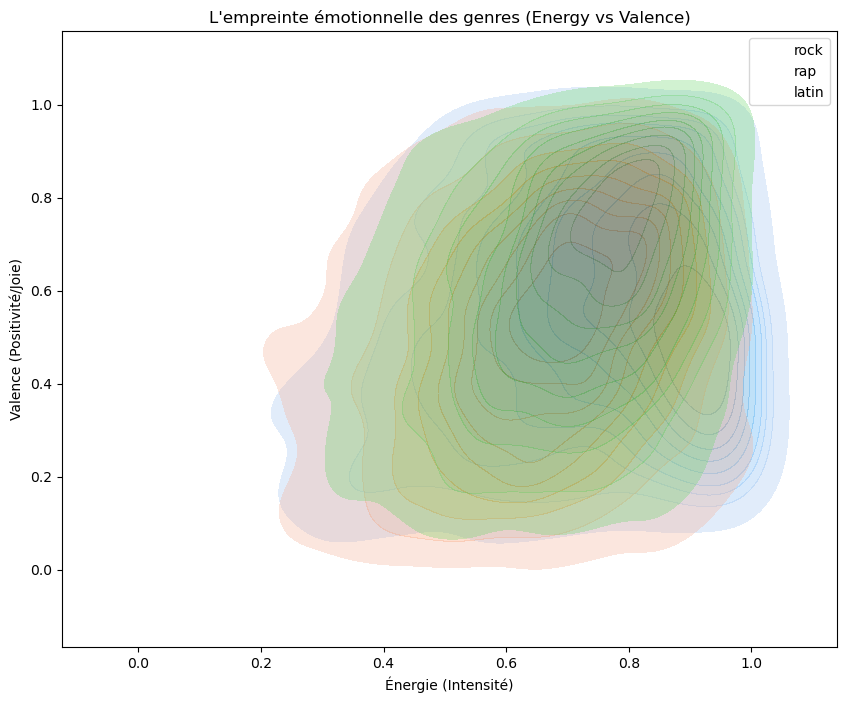

In [ ]:
# Sélection et conversion
mood_data = data_clean[['energy', 'valence', 'playlist_genre']].copy()
mood_data['energy'] = mood_data['energy'].astype(float)
mood_data['valence'] = mood_data['valence'].astype(float)

plt.figure(figsize=(10, 8))

# On trace les courbes de densité pour 3 genres contrastés
for g in ['rock', 'rap', 'latin']:
    subset = mood_data[mood_data['playlist_genre'] == g]
    sns.kdeplot(x=subset['energy'], y=subset['valence'], label=g, shade=True, alpha=0.3)

plt.title("L'empreinte émotionnelle des genres (Energy vs Valence)")
plt.xlabel("Énergie (Intensité)")
plt.ylabel("Valence (Positivité/Joie)")
plt.legend()
plt.show()

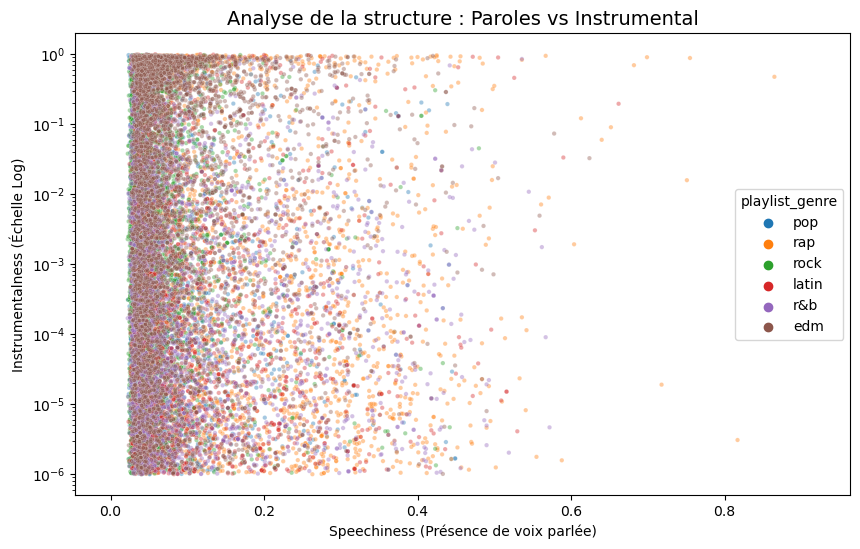

In [ ]:
# Préparation
comp_data = data_clean[['speechiness', 'instrumentalness', 'playlist_genre']].copy()
comp_data['speechiness'] = comp_data['speechiness'].astype(float)
comp_data['instrumentalness'] = comp_data['instrumentalness'].astype(float)

plt.figure(figsize=(10, 6))

# Scatter plot avec une taille de point basée sur le genre
sns.scatterplot(
    data=comp_data, 
    x='speechiness', 
    y='instrumentalness', 
    hue='playlist_genre', 
    s=10, 
    alpha=0.4
)

plt.yscale('log') # On utilise une échelle log car instrumentalness a souvent beaucoup de 0
plt.title("Analyse de la structure : Paroles vs Instrumental", fontsize=14)
plt.xlabel("Speechiness (Présence de voix parlée)")
plt.ylabel("Instrumentalness (Échelle Log)")
plt.show()

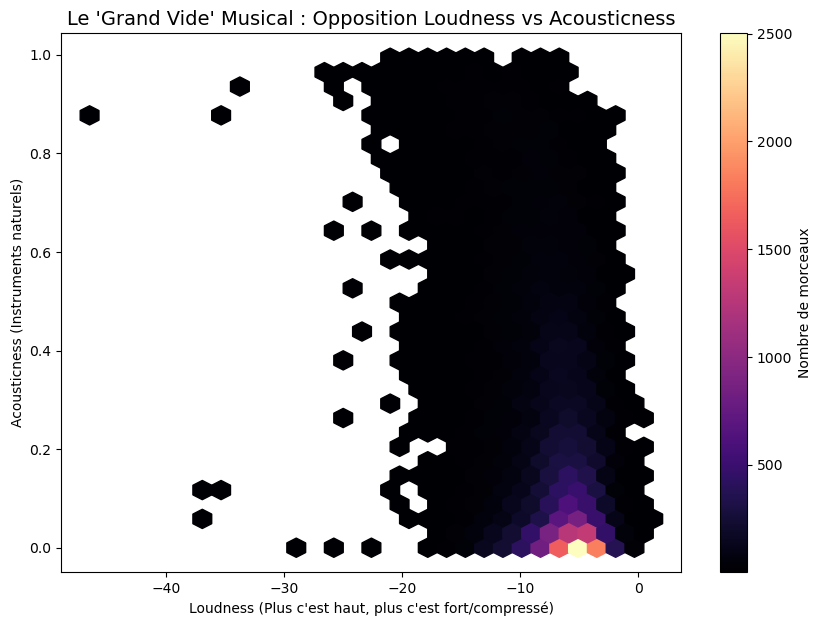

In [ ]:
# On utilise Loudness (Volume) et Acousticness qui sont souvent opposées
plt.figure(figsize=(10, 7))
hb = plt.hexbin(
    data_clean['loudness'].astype(float), 
    data_clean['acousticness'].astype(float), 
    gridsize=30, cmap='magma', mincnt=1
)
cb = plt.colorbar(hb, label='Nombre de morceaux')

plt.title("Le 'Grand Vide' Musical : Opposition Loudness vs Acousticness", fontsize=14)
plt.xlabel("Loudness (Plus c'est haut, plus c'est fort/compressé)")
plt.ylabel("Acousticness (Instruments naturels)")
plt.show()

# INTERPRÉTATION : On voit souvent deux îles : une île "Radio/Club" (Fort/Électrique) 
# et une île "Niche/Acoustique" (Calme/Naturel).

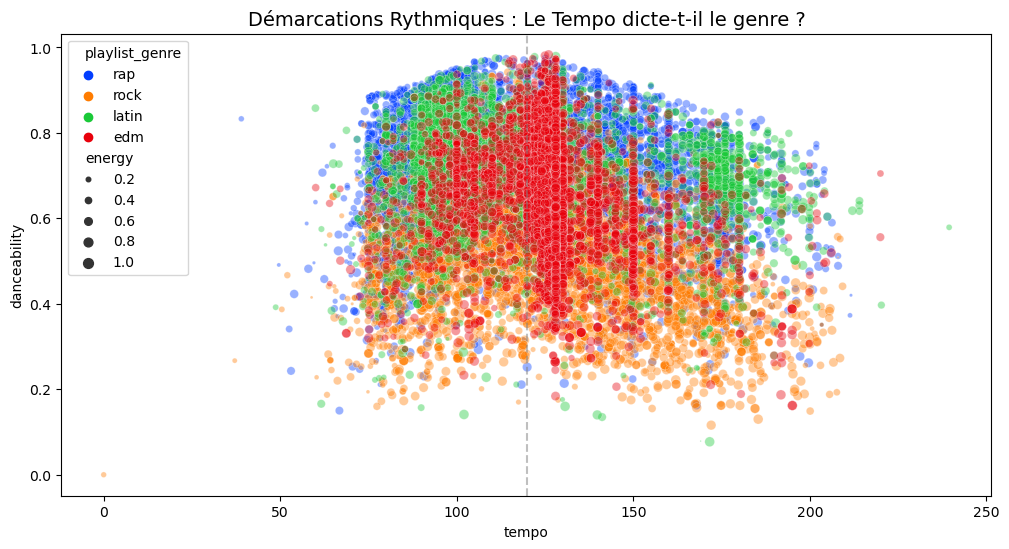

In [ ]:
plt.figure(figsize=(12, 6))

# On filtre sur les genres majeurs pour la clarté
major_genres = ['rap', 'rock', 'edm', 'latin']
df_filtered = data_clean[data_clean['playlist_genre'].isin(major_genres)].copy()

sns.scatterplot(
    data=df_filtered, 
    x=df_filtered['tempo'].astype(float), 
    y=df_filtered['danceability'].astype(float), 
    hue='playlist_genre',
    size=df_filtered['energy'].astype(float), # Taille des points selon l'énergie
    sizes=(1, 50),
    alpha=0.4,
    palette='bright'
)

plt.title("Démarcations Rythmiques : Le Tempo dicte-t-il le genre ?", fontsize=14)
plt.axvline(120, color='grey', linestyle='--', alpha=0.5) # BPM classique Club
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

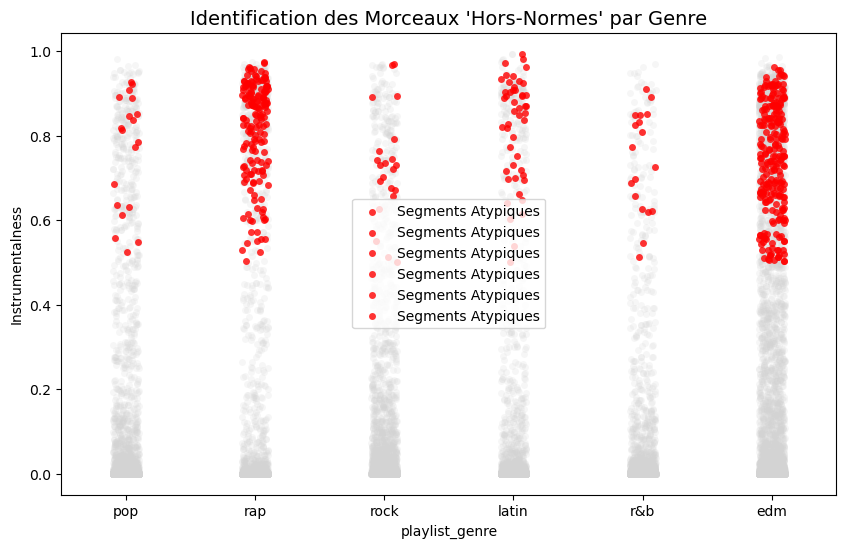

In [ ]:
# Création d'un score de "Bizarrerie"
# On cherche les morceaux très instrumentaux (instrumentalness > 0.5) 
# MAIS avec beaucoup de voix (speechiness > 0.1) -> c'est rare !
exp_segments = data_clean[
    (data_clean['instrumentalness'].astype(float) > 0.5) & 
    (data_clean['speechiness'].astype(float) > 0.1)
]

plt.figure(figsize=(10, 6))
sns.stripplot(
    data=data_clean, x='playlist_genre', y='instrumentalness', 
    color='lightgrey', alpha=0.2, jitter=True
)
sns.stripplot(
    data=exp_segments, x='playlist_genre', y='instrumentalness', 
    color='red', alpha=0.8, jitter=True, label="Segments Atypiques"
)

plt.title("Identification des Morceaux 'Hors-Normes' par Genre", fontsize=14)
plt.ylabel("Instrumentalness")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


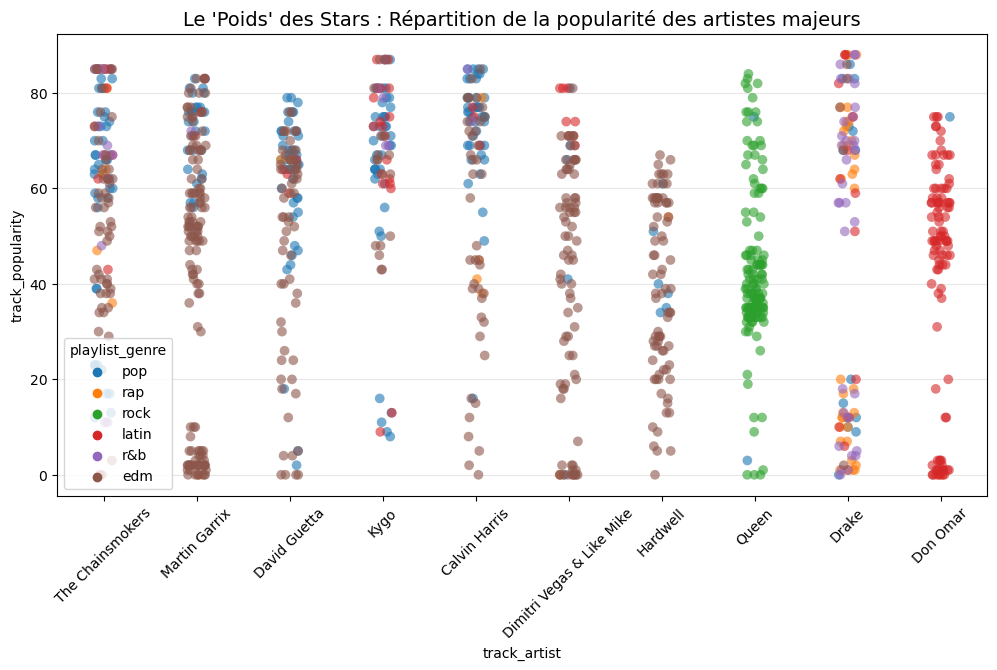

In [ ]:
# 1. Trouver les top 10 artistes par nombre de chansons
top_artists = data_clean['track_artist'].value_counts().nlargest(10).index
df_top = data_clean[data_clean['track_artist'].isin(top_artists)].copy()
df_top['track_popularity'] = df_top['track_popularity'].astype(float)
df_top['energy'] = df_top['energy'].astype(float)

plt.figure(figsize=(12, 6))
# Stripplot : chaque point est une chanson, alignée par artiste
sns.stripplot(
    data=df_top, x='track_artist', y='track_popularity', 
    hue='playlist_genre', jitter=True, alpha=0.6, size=7
)

plt.xticks(rotation=45)
plt.title("Le 'Poids' des Stars : Répartition de la popularité des artistes majeurs", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()

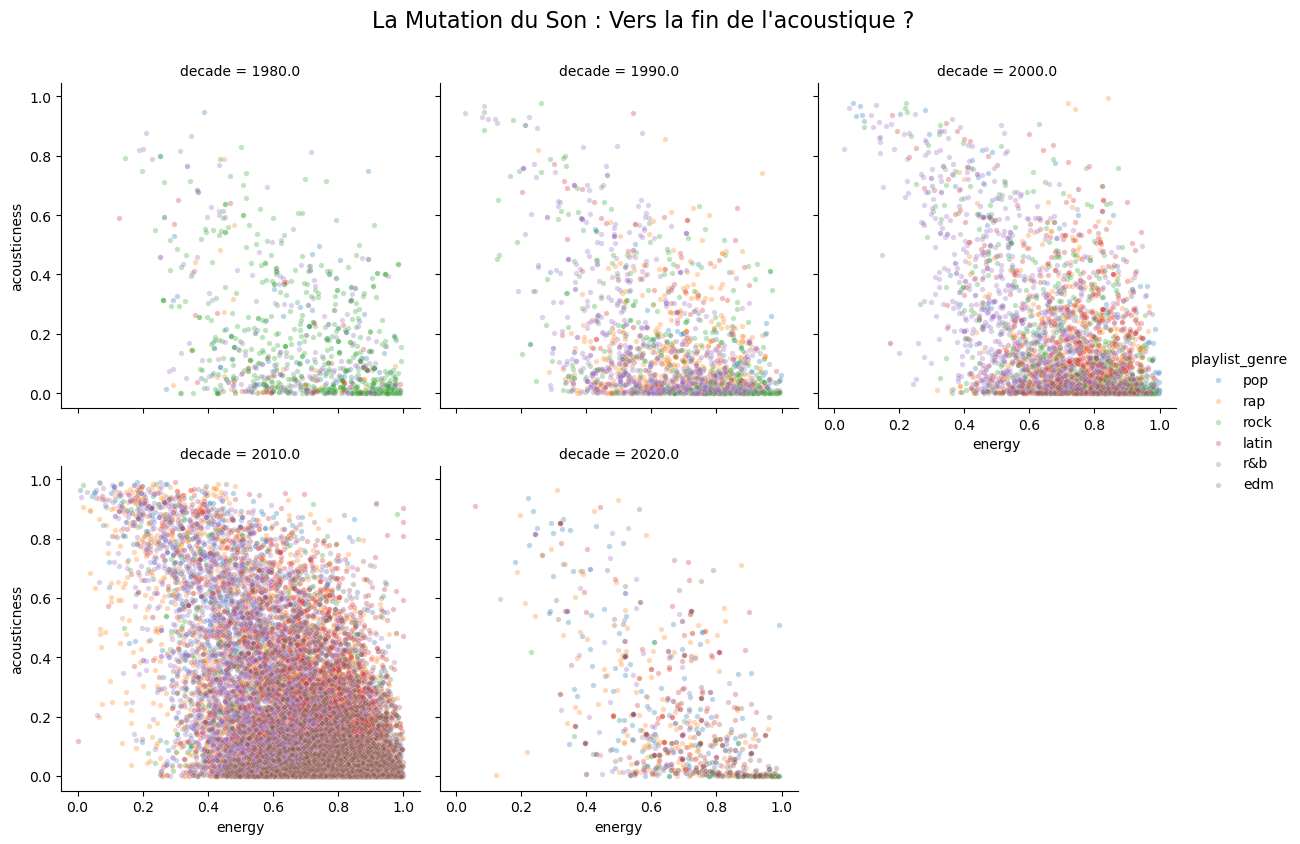

In [ ]:
# 1. Créer des catégories de décennies
data_clean['decade'] = (data_clean['year'] // 10) * 10
# On prend les décennies les plus représentées
decades = [1980, 1990, 2000, 2010, 2020]
df_dec = data_clean[data_clean['decade'].isin(decades)].copy()

# 2. FacetGrid : un graphique par décennie
g = sns.FacetGrid(df_dec, col="decade", hue="playlist_genre", col_wrap=3, height=4)
g.map(sns.scatterplot, "energy", "acousticness", alpha=0.3, s=15)

g.add_legend()
g.fig.suptitle("La Mutation du Son : Vers la fin de l'acoustique ?", y=1.05, fontsize=16)
plt.show()

# INTERPRÉTATION : Tu verras qu'en 1980, les points sont partout. 
# En 2020, ils sont presque tous tassés en bas à droite (Haute Énergie / Basse Acoustique).